# Static Edge-Weight Metrics for Drone-ACO Monitoring

Computes three precomputable components from the Roxborough SUMO network:

| Component | What it captures | Source |
|---|---|---|
| `f_demand` | V_e / q_c (LOS volume-to-capacity) | Janfeshanaraghi 2025 + Rohaert 2025 |
| `f_topo` | Evacuation betweenness centrality | Graph structural |
| `f_redundancy` | 1 / edge connectivity (bridges = 1.0) | Graph structural |

Capacity is computed analytically from the Daganzo reduction of SUMO's Krauss
car-following model. Demand uses static all-or-nothing assignment
(Intini 2019, four-step model steps 1-2).

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from metrics import (
    load_sumo_network, build_graphs,
    annotate_capacity, daganzo_capacity,
    assign_static_demand, compute_f_demand,
    compute_f_topo, compute_f_redundancy,
    combine_weights,
)
from metrics.demand import default_origins, default_exits

## 1. Load the Roxborough network

In [2]:
NET_FILE = "../../../../../../Examples/NFDRS4_Behave/Roxborough/sumo/rox_big.net.xml"

sumo_net = load_sumo_network(NET_FILE)
DG, UG = build_graphs(sumo_net)

print(f"Directed:   {DG.number_of_nodes()} nodes, {DG.number_of_edges()} edges")
print(f"Undirected: {UG.number_of_nodes()} nodes, {UG.number_of_edges()} edges")

Directed:   1026 nodes, 2328 edges
Undirected: 1026 nodes, 1295 edges


In [3]:
def pos_of(G):
    return {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in G.nodes()}

def draw_edge_values(G, values, title, cmap='viridis', ax=None,
                     vmin=None, vmax=None, width_scale=1.6):
    """Draw G colouring edges by the given dict {edge: value}."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(13, 13))
    pos = pos_of(G)
    edges = list(G.edges())
    # Use undirected lookup so dict {(u,v)} matches edges stored as (u,v) or (v,u)
    vals = []
    for u, v in edges:
        if (u, v) in values:
            vals.append(values[(u, v)])
        elif (v, u) in values:
            vals.append(values[(v, u)])
        else:
            vals.append(0.0)
    vals = np.array(vals)
    vmin = vals.min() if vmin is None else vmin
    vmax = vals.max() if vmax is None else vmax
    if vmax == vmin:
        vmax = vmin + 1e-9

    # Line widths proportional to value so high-weight edges pop
    widths = 0.4 + width_scale * (vals - vmin) / (vmax - vmin)

    cmap_obj = plt.cm.get_cmap(cmap)
    colors = cmap_obj((vals - vmin) / (vmax - vmin))
    nx.draw_networkx_edges(G, pos, edgelist=edges, ax=ax,
                           edge_color=colors, width=widths)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1, node_color='black', alpha=0.3)

    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.6, label=title)
    ax.set_title(title, fontsize=14)
    ax.set_aspect('equal')
    ax.axis('off')
    return ax

## 2. Capacity (Daganzo / Krauss)

Annotate every edge with q_c, then visualize capacity across the network.

In [4]:
annotate_capacity(DG)
annotate_capacity(UG)

# Example calculation for a single residential lane at 13.89 m/s (50 km/h)
demo = daganzo_capacity(v_f=13.89, num_lanes=1)
print("Example — residential, 1 lane, 50 km/h:")
for k, v in demo.items():
    print(f"  {k:<24} {v:.4f}")

caps = {(u, v): d['q_c_edge_per_hour'] for u, v, d in UG.edges(data=True)}
print(f"\nNetwork capacity range: {min(caps.values()):.0f} — {max(caps.values()):.0f} veh/h")

Example — residential, 1 lane, 50 km/h:
  k_j                      0.1333
  k_c                      0.0468
  q_c_per_lane             0.6494
  q_c_edge                 0.6494
  q_c_per_lane_per_hour    2337.7279
  q_c_edge_per_hour        2337.7279

Network capacity range: 2155 — 17036 veh/h


/var/folders/s6/_jlt2w690_b4g96493_vlzcm0000gn/T/ipykernel_53407/586194638.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


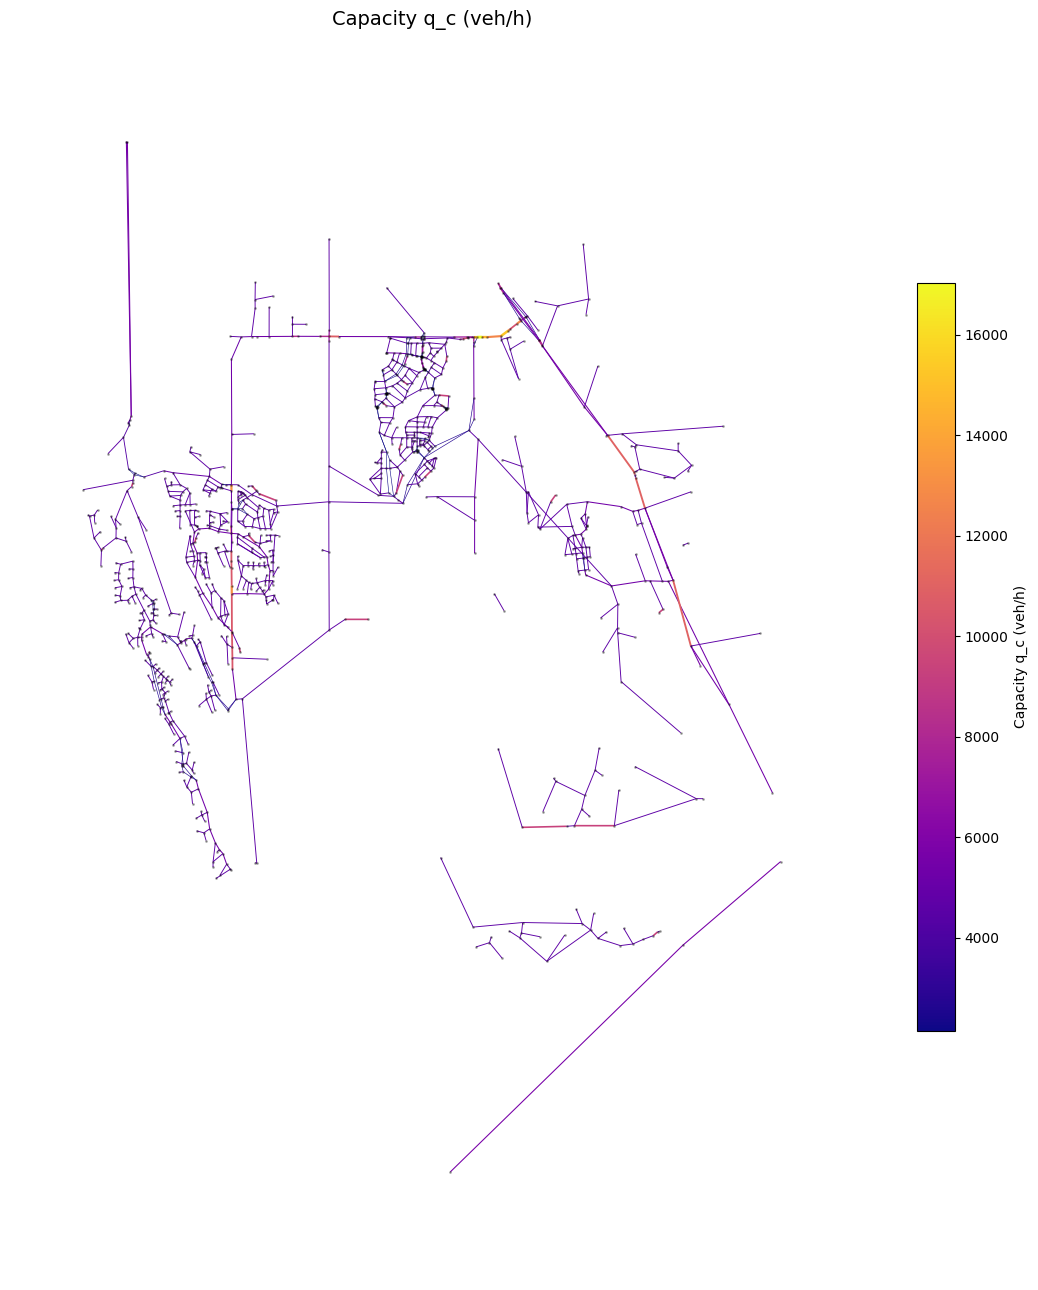

In [5]:
draw_edge_values(UG, caps, 'Capacity q_c (veh/h)', cmap='plasma')
plt.tight_layout(); plt.show()

## 3. Pick origins and exits

Default heuristics:
- **Origins**: nodes incident to any residential / unclassified edge
- **Exits**: degree-1 nodes at the end of major (trunk/secondary) roads — the network's boundary to the outside world

If you have real GIS parcel and safe-zone data, replace these lists.

Origins: 903
Exits:   7 -> ['88534655', '88534518', '7777187757', '1322569187', '721792860', '7907235687', '1322569164']


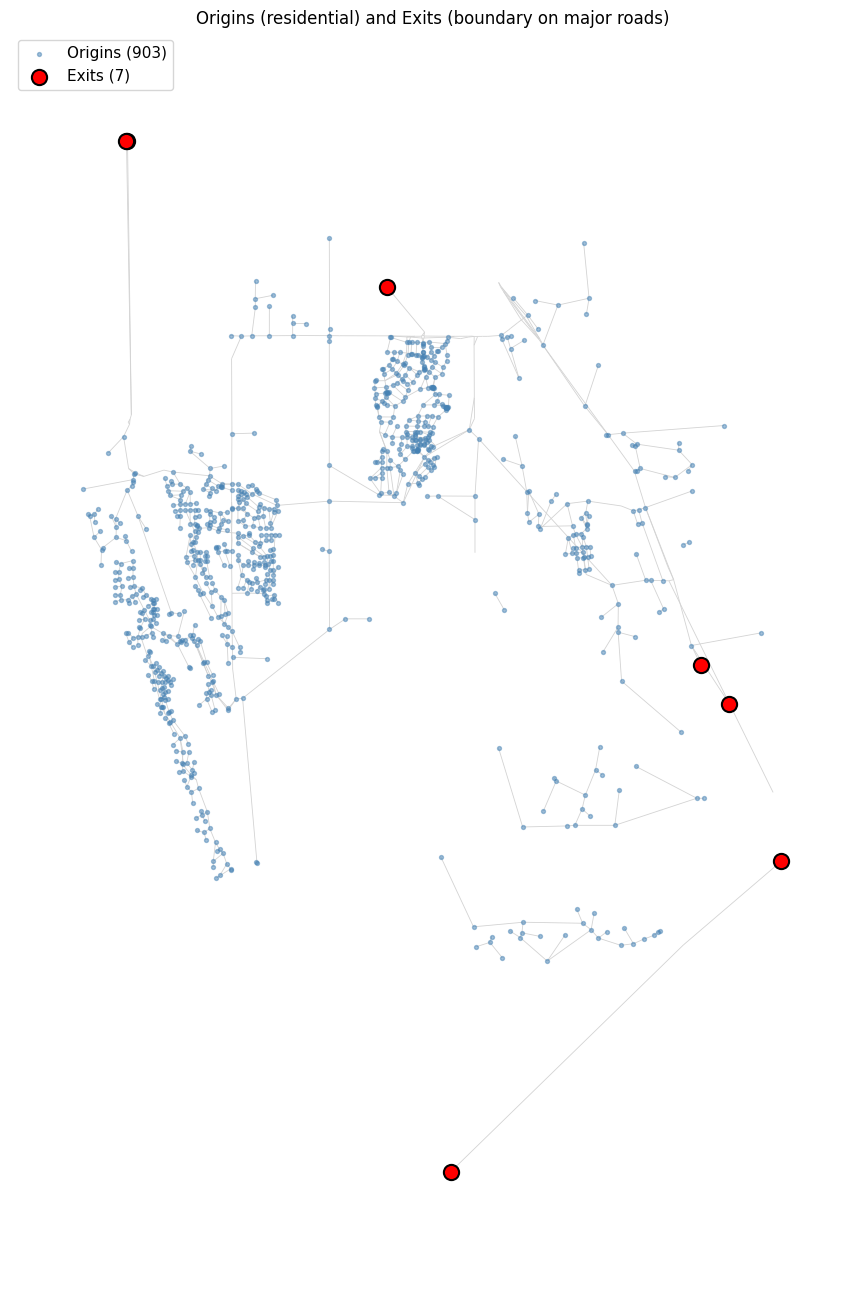

In [6]:
origins = default_origins(DG)
exits = default_exits(DG)
print(f"Origins: {len(origins)}")
print(f"Exits:   {len(exits)} -> {exits}")

fig, ax = plt.subplots(figsize=(13, 13))
pos = pos_of(UG)
nx.draw_networkx_edges(UG, pos, ax=ax, edge_color='lightgray', width=0.6)
nx.draw_networkx_nodes(UG, pos, nodelist=origins, ax=ax,
                       node_size=8, node_color='steelblue', alpha=0.5, label=f'Origins ({len(origins)})')
nx.draw_networkx_nodes(UG, pos, nodelist=exits, ax=ax,
                       node_size=120, node_color='red', edgecolors='black',
                       linewidths=1.5, label=f'Exits ({len(exits)})')
ax.legend(fontsize=11, loc='upper left')
ax.set_title('Origins (residential) and Exits (boundary on major roads)')
ax.set_aspect('equal'); ax.axis('off')
plt.tight_layout(); plt.show()

## 4. f_demand — static assignment + volume-to-capacity

Each origin sends `vehicles_per_origin` trips along the shortest travel-time path to its nearest exit. We then divide by the hourly capacity to get the LOS ratio V_e / q_c.

In [7]:
volumes, unassigned = assign_static_demand(DG, origins, exits,
                                           vehicles_per_origin=1.5)
print(f"Loaded edges: {len(volumes)} / {DG.number_of_edges()}")
print(f"Unassigned origins (no path to any exit): {len(unassigned)}")
print(f"Peak edge volume: {max(volumes.values()):.0f} vehicles")

f_demand = compute_f_demand(DG, volumes, evacuation_duration_hours=2.0)
print(f"\nf_demand stats over all edges:")
vals = np.array(list(f_demand.values()))
print(f"  mean {vals.mean():.3f}, max {vals.max():.3f}, >50% loaded: {(vals>0.5).sum()} edges")

Loaded edges: 945 / 2328
Unassigned origins (no path to any exit): 48
Peak edge volume: 1062 vehicles

f_demand stats over all edges:
  mean 0.003, max 0.230, >50% loaded: 0 edges


/var/folders/s6/_jlt2w690_b4g96493_vlzcm0000gn/T/ipykernel_53407/586194638.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


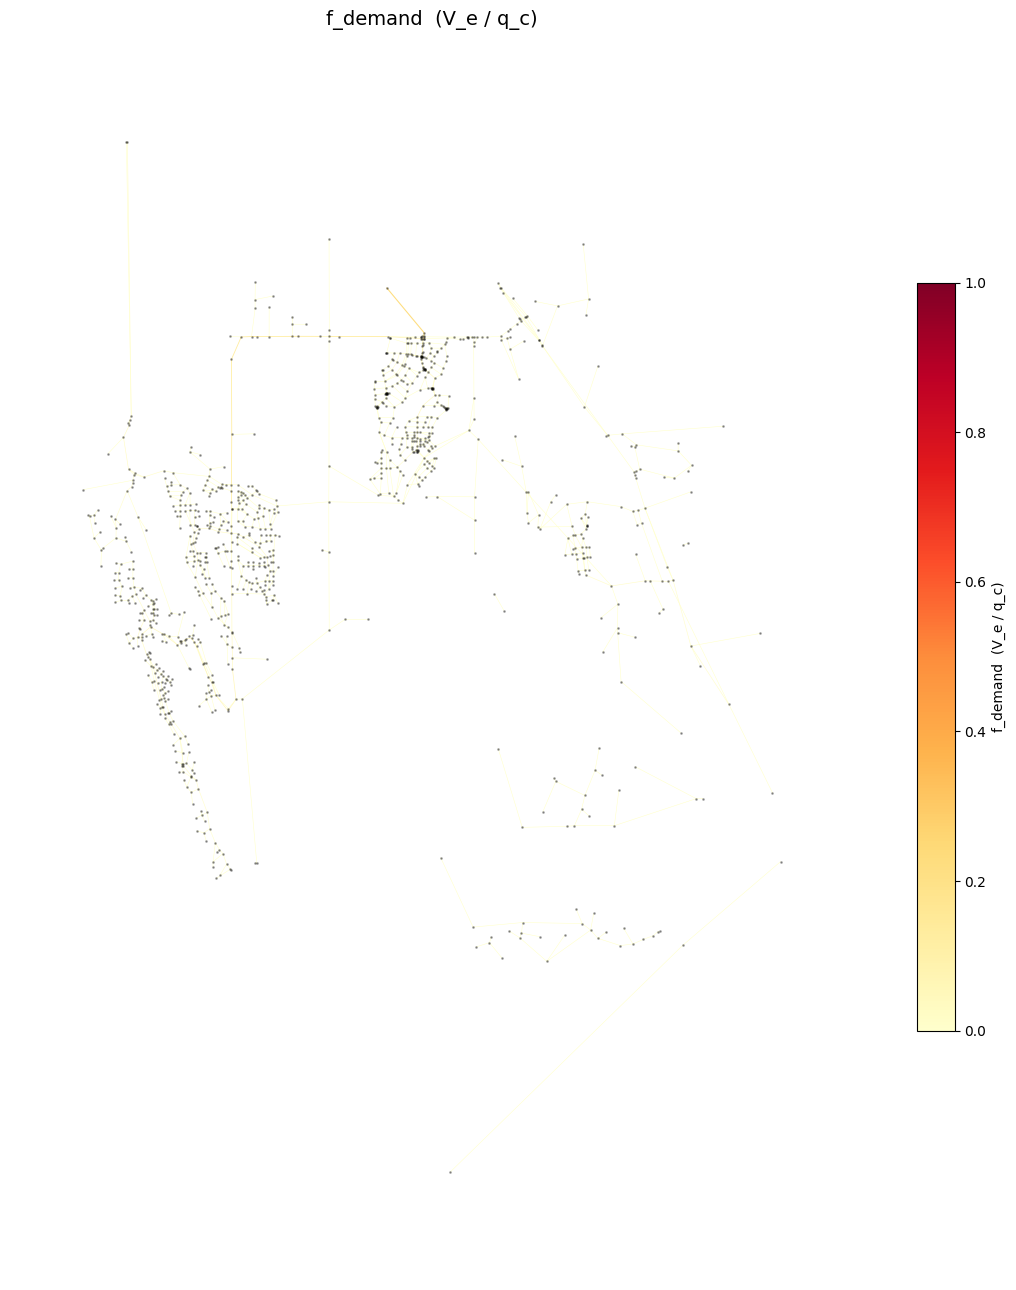

In [8]:
# For visualization on the undirected graph, take max over both directions
f_demand_ug = {}
for u, v in UG.edges():
    f_demand_ug[(u, v)] = max(f_demand.get((u, v), 0.0),
                               f_demand.get((v, u), 0.0))

draw_edge_values(UG, f_demand_ug, 'f_demand  (V_e / q_c)', cmap='YlOrRd', vmin=0, vmax=1)
plt.tight_layout(); plt.show()

## 5. f_topo — evacuation betweenness

f_topo: mean 0.070, max 1.000, top-1% threshold 0.968


/var/folders/s6/_jlt2w690_b4g96493_vlzcm0000gn/T/ipykernel_53407/586194638.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


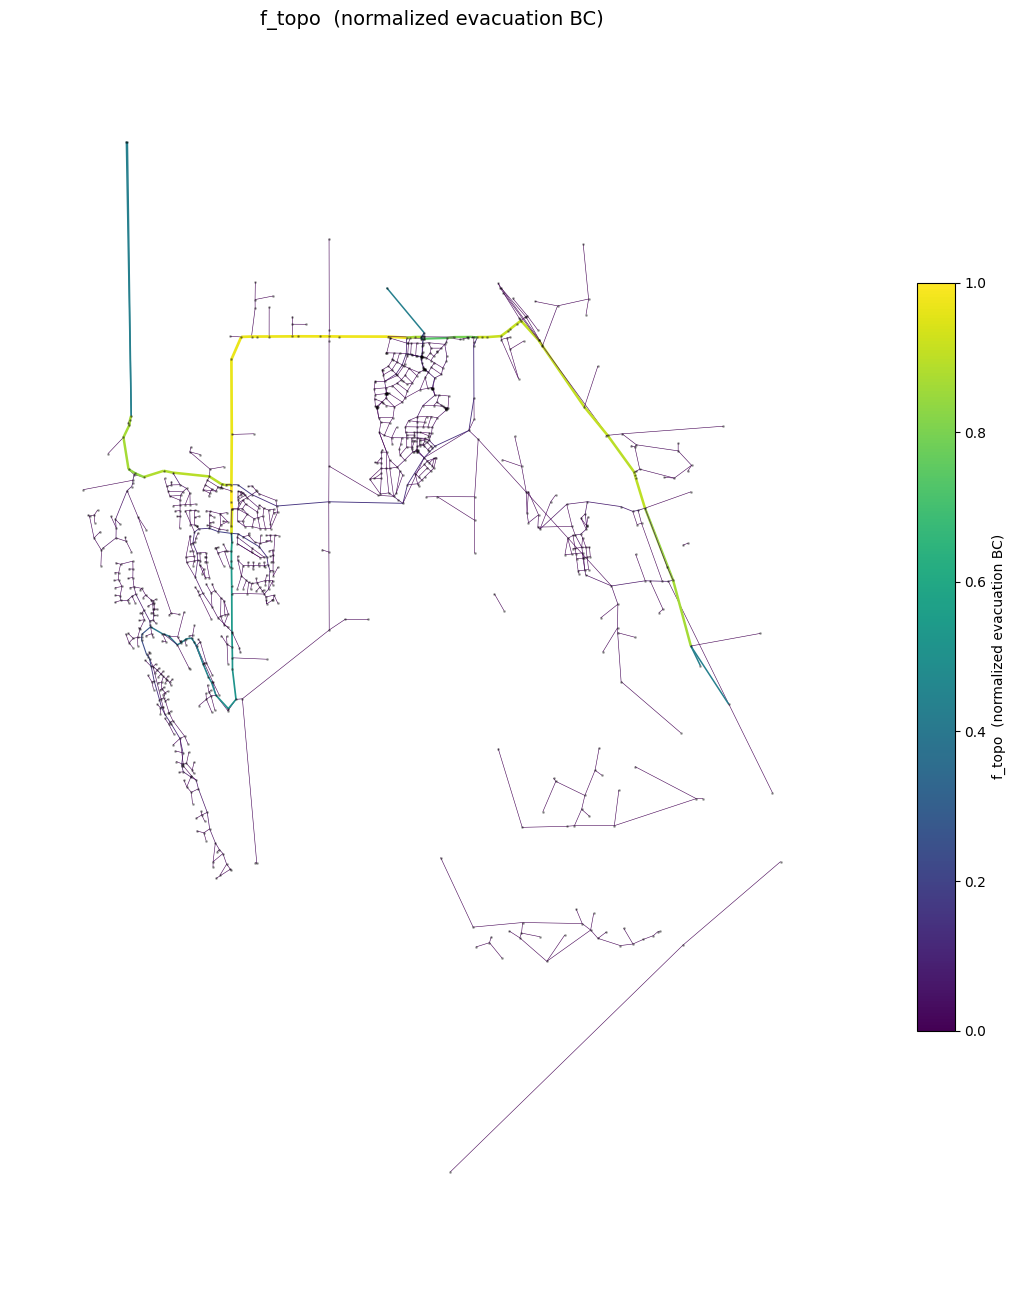

In [9]:
f_topo = compute_f_topo(UG, origins, exits, weight='travel_time')
vals = np.array(list(f_topo.values()))
print(f"f_topo: mean {vals.mean():.3f}, max {vals.max():.3f}, top-1% threshold {np.percentile(vals, 99):.3f}")

draw_edge_values(UG, f_topo, 'f_topo  (normalized evacuation BC)', cmap='viridis', vmin=0, vmax=1)
plt.tight_layout(); plt.show()

## 6. f_redundancy — bridges and edge connectivity

Bridges (f_redundancy = 1.0): 375 / 1295 edges
Non-bridges (f_redundancy = 0.5): 920


/var/folders/s6/_jlt2w690_b4g96493_vlzcm0000gn/T/ipykernel_53407/586194638.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


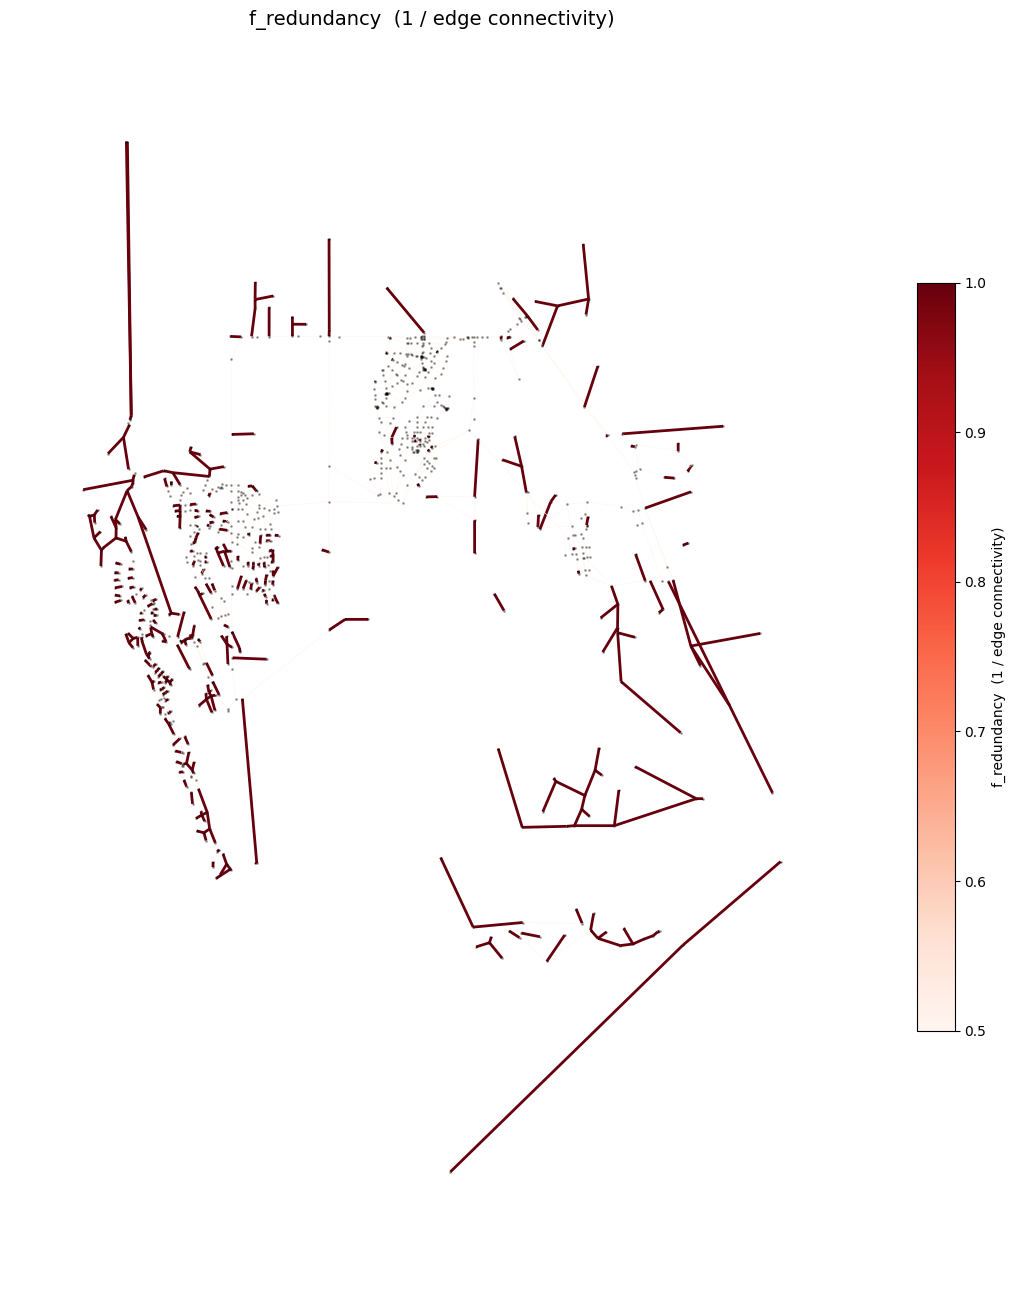

In [10]:
f_redundancy = compute_f_redundancy(UG)
n_bridges = sum(1 for v in f_redundancy.values() if v == 1.0)
print(f"Bridges (f_redundancy = 1.0): {n_bridges} / {UG.number_of_edges()} edges")
print(f"Non-bridges (f_redundancy = 0.5): {UG.number_of_edges() - n_bridges}")

draw_edge_values(UG, f_redundancy, 'f_redundancy  (1 / edge connectivity)',
                 cmap='Reds', vmin=0.5, vmax=1.0)
plt.tight_layout(); plt.show()

## 7. Combined static weight

W(e) = 0.5 · f_demand + 0.3 · f_topo + 0.2 · f_redundancy

Tweak the weights for your use case — if you care most about capacity exceedance
under evacuation (Janfeshanaraghi's finding), keep `w_demand` high.

Combined W: mean 0.153, max 0.471
Top 10% of edges (W > 0.205): drone-priority scan targets


/var/folders/s6/_jlt2w690_b4g96493_vlzcm0000gn/T/ipykernel_53407/586194638.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


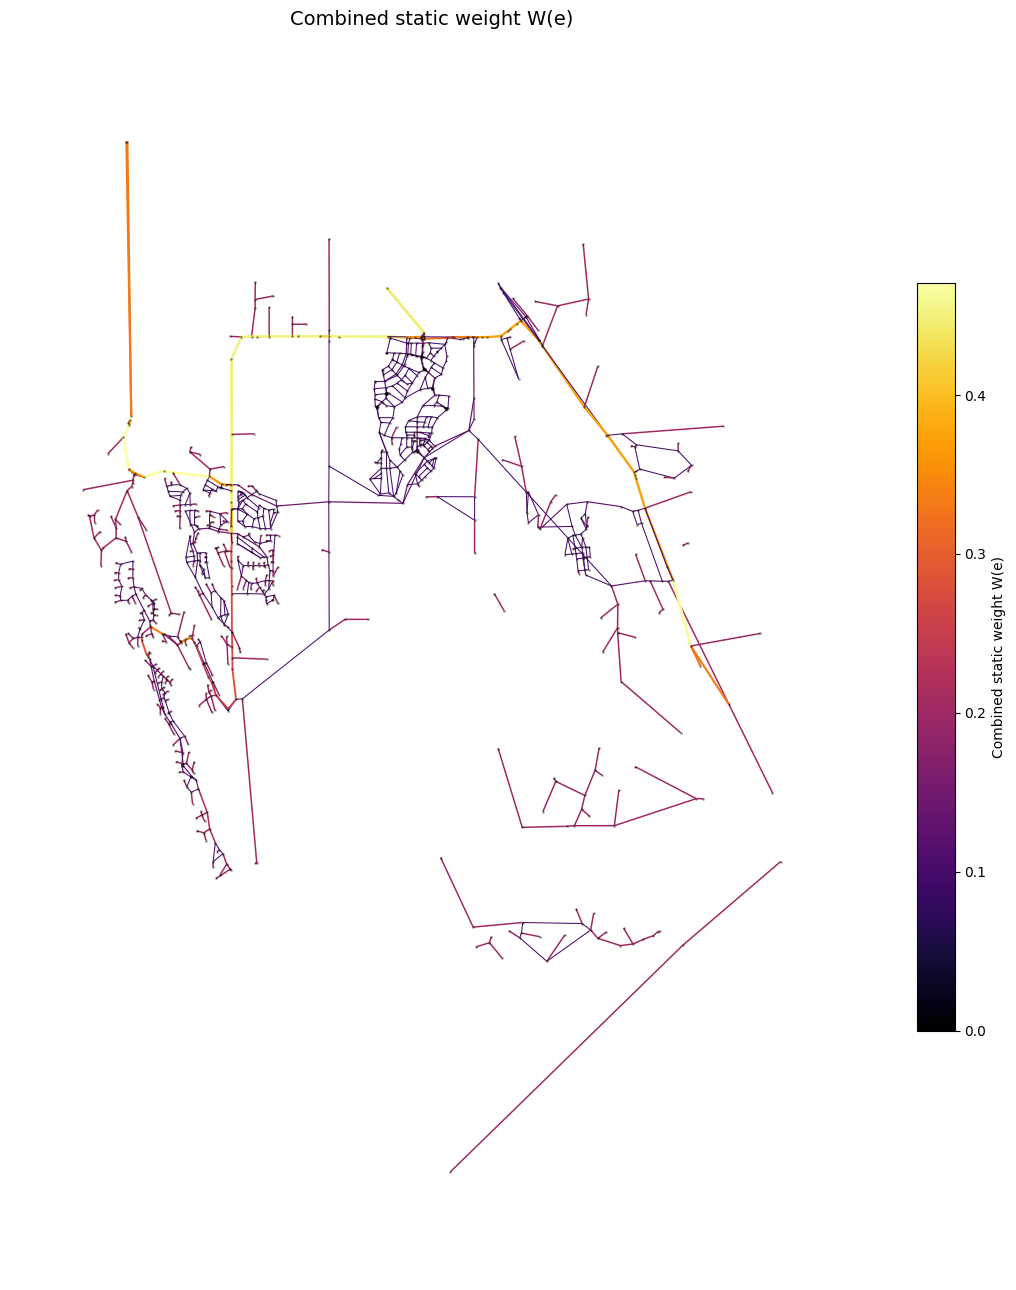

In [11]:
edges = list(UG.edges())
W = combine_weights(edges, f_demand_ug, f_topo, f_redundancy,
                    w_demand=0.5, w_topo=0.3, w_redundancy=0.2)

vals = np.array(list(W.values()))
print(f"Combined W: mean {vals.mean():.3f}, max {vals.max():.3f}")
print(f"Top 10% of edges (W > {np.percentile(vals, 90):.3f}): drone-priority scan targets")

draw_edge_values(UG, W, 'Combined static weight W(e)', cmap='inferno', vmin=0, vmax=vals.max())
plt.tight_layout(); plt.show()

## 8. Side-by-side comparison of all three components

/var/folders/s6/_jlt2w690_b4g96493_vlzcm0000gn/T/ipykernel_53407/586194638.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


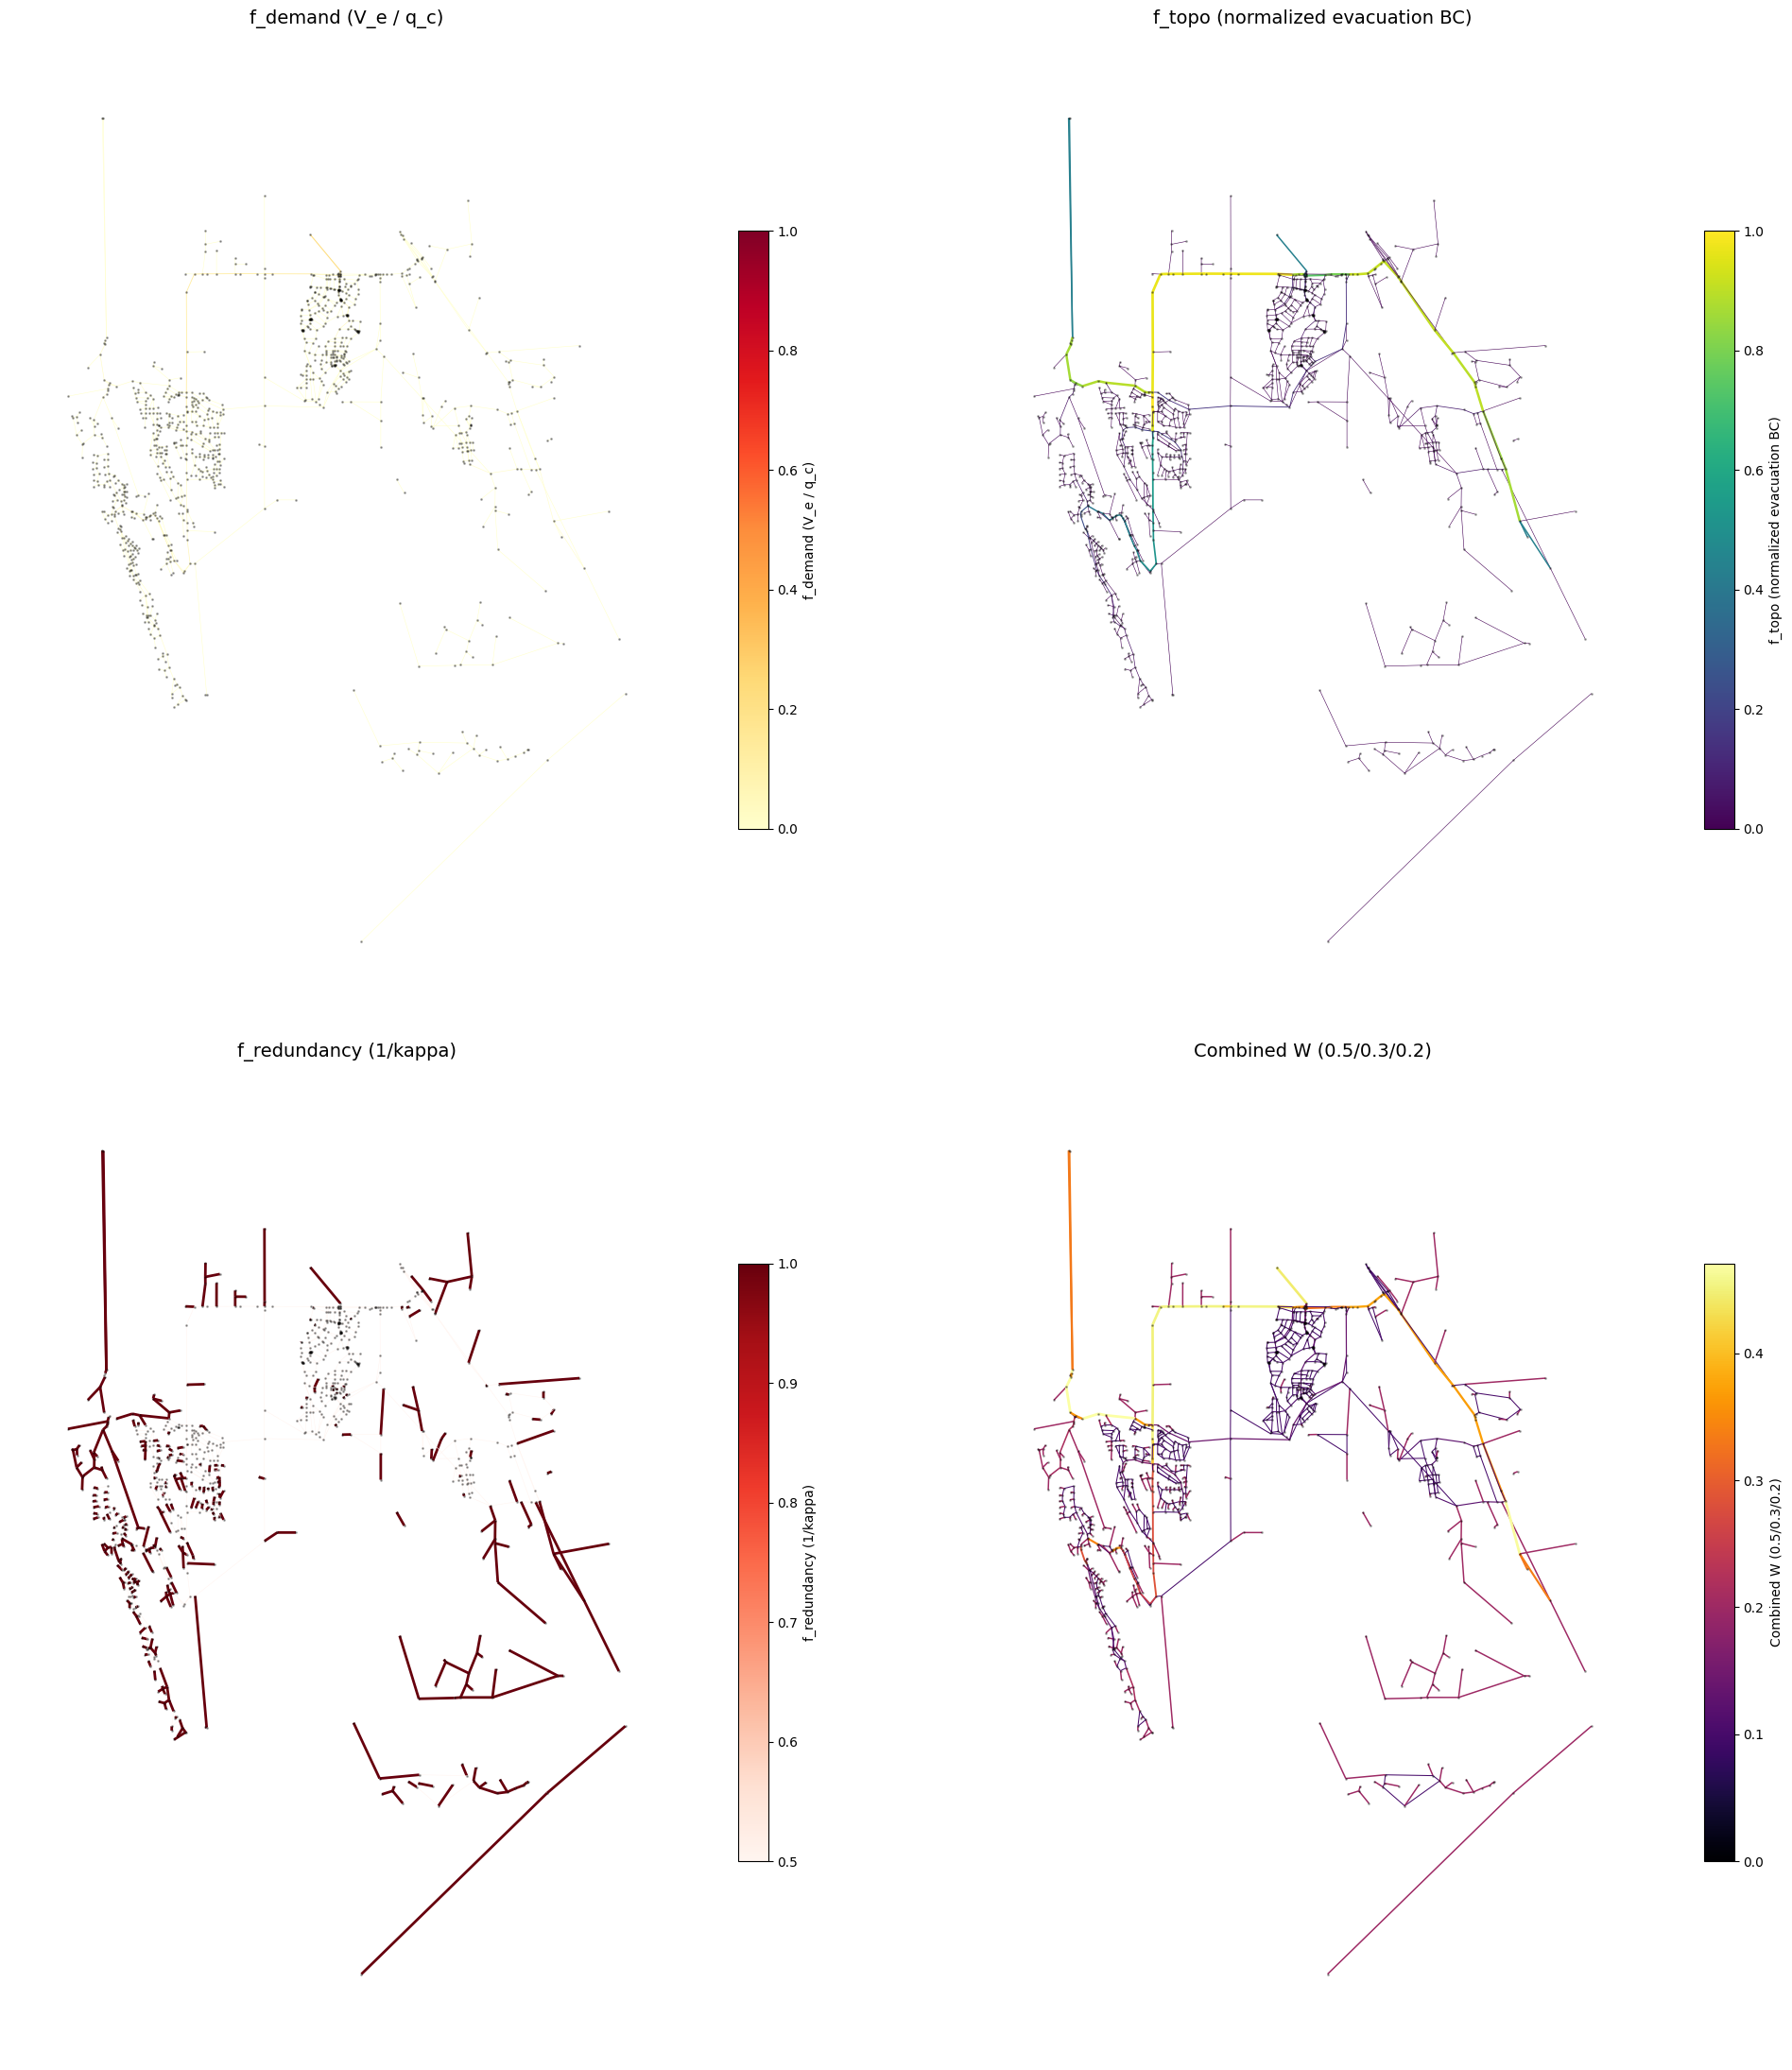

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(22, 22))
draw_edge_values(UG, f_demand_ug, 'f_demand (V_e / q_c)',
                 cmap='YlOrRd', ax=axes[0, 0], vmin=0, vmax=1)
draw_edge_values(UG, f_topo, 'f_topo (normalized evacuation BC)',
                 cmap='viridis', ax=axes[0, 1], vmin=0, vmax=1)
draw_edge_values(UG, f_redundancy, 'f_redundancy (1/kappa)',
                 cmap='Reds', ax=axes[1, 0], vmin=0.5, vmax=1)
draw_edge_values(UG, W, 'Combined W (0.5/0.3/0.2)',
                 cmap='inferno', ax=axes[1, 1], vmin=0, vmax=vals.max())
plt.tight_layout(); plt.show()

## 9. Top drone-priority edges

In [13]:
top = sorted(W.items(), key=lambda kv: -kv[1])[:20]
print(f"{'edge':<35} {'W':>6} {'f_demand':>10} {'f_topo':>8} {'f_red':>6}  road type")
print('-' * 90)
for (u, v), w in top:
    etype = UG[u][v].get('edge_type', '?')
    fd = f_demand_ug.get((u, v), f_demand_ug.get((v, u), 0))
    ft = f_topo.get((u, v), f_topo.get((v, u), 0))
    fr = f_redundancy.get((u, v), f_redundancy.get((v, u), 0))
    print(f"{u[:15]:<15}-> {v[:15]:<15}  {w:>6.3f}  {fd:>10.3f}  {ft:>8.3f}  {fr:>6.2f}  {etype}")

edge                                     W   f_demand   f_topo  f_red  road type
------------------------------------------------------------------------------------------
177384720      -> 440740846         0.471       0.022     0.865    1.00  highway.secondary
177384720      -> 559877478         0.471       0.022     0.866    1.00  highway.secondary
88510228       -> 88510215          0.470       0.011     0.882    1.00  highway.secondary
801214485      -> 801226323         0.469       0.003     0.893    1.00  highway.secondary
88510215       -> 801226323         0.469       0.009     0.882    1.00  highway.secondary
4983109921     -> 440740855         0.468       0.017     0.865    1.00  highway.secondary
cluster_1011632-> cluster_7907235   0.465       0.011     0.866    1.00  highway.trunk
1398988754     -> 4199843666        0.456       0.114     0.997    0.50  highway.secondary
88485237       -> 8176401977        0.456       0.126     0.976    0.50  highway.secondary
8176401977   